In [ ]:
!pip install pyfolio
!pip install backtrader
!pip install quantstats
!pip install -U seaborn
!pip install -U matplotlip
!pip install --upgrade tensorflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 1.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 kB 1.8 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement matplotlip (from versions: none)
ERROR: No matching distribution found for matplotlip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/

In [ ]:
from google.colab import files
import pandas as pd
import numpy as np

In [ ]:
import backtrader as bt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.layers import Dense, Masking
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

In [ ]:
import warnings
warnings.filterwarnings('ignore')


Processing AAA:
BUY CREATE, 2012-08-20, Price: 4.09
BUY CREATE, 2012-11-01, Price: 3.25
SELL CREATE, 2012-11-07, Price: 3.20
BUY CREATE, 2012-12-18, Price: 3.32
SELL CREATE, 2013-03-15, Price: 3.53
BUY CREATE, 2013-05-23, Price: 3.63
SELL CREATE, 2013-07-10, Price: 3.61
BUY CREATE, 2013-08-28, Price: 3.61
SELL CREATE, 2013-09-09, Price: 3.50
BUY CREATE, 2013-10-04, Price: 3.99
SELL CREATE, 2014-04-15, Price: 5.84
BUY CREATE, 2014-06-25, Price: 5.19
SELL CREATE, 2014-10-17, Price: 5.82
BUY CREATE, 2014-11-26, Price: 6.04
SELL CREATE, 2014-12-26, Price: 5.03
BUY CREATE, 2015-05-15, Price: 5.07
SELL CREATE, 2015-08-19, Price: 5.07
BUY CREATE, 2015-10-09, Price: 4.99
SELL CREATE, 2016-09-14, Price: 13.98
BUY CREATE, 2017-02-22, Price: 13.83
SELL CREATE, 2017-08-03, Price: 17.82
BUY CREATE, 2017-09-11, Price: 18.12
SELL CREATE, 2017-11-02, Price: 16.65
BUY CREATE, 2017-12-22, Price: 18.38
SELL CREATE, 2018-02-08, Price: 15.91
BUY CREATE, 2018-06-07, Price: 16.58
SELL CREATE, 2018-07-04, Pr

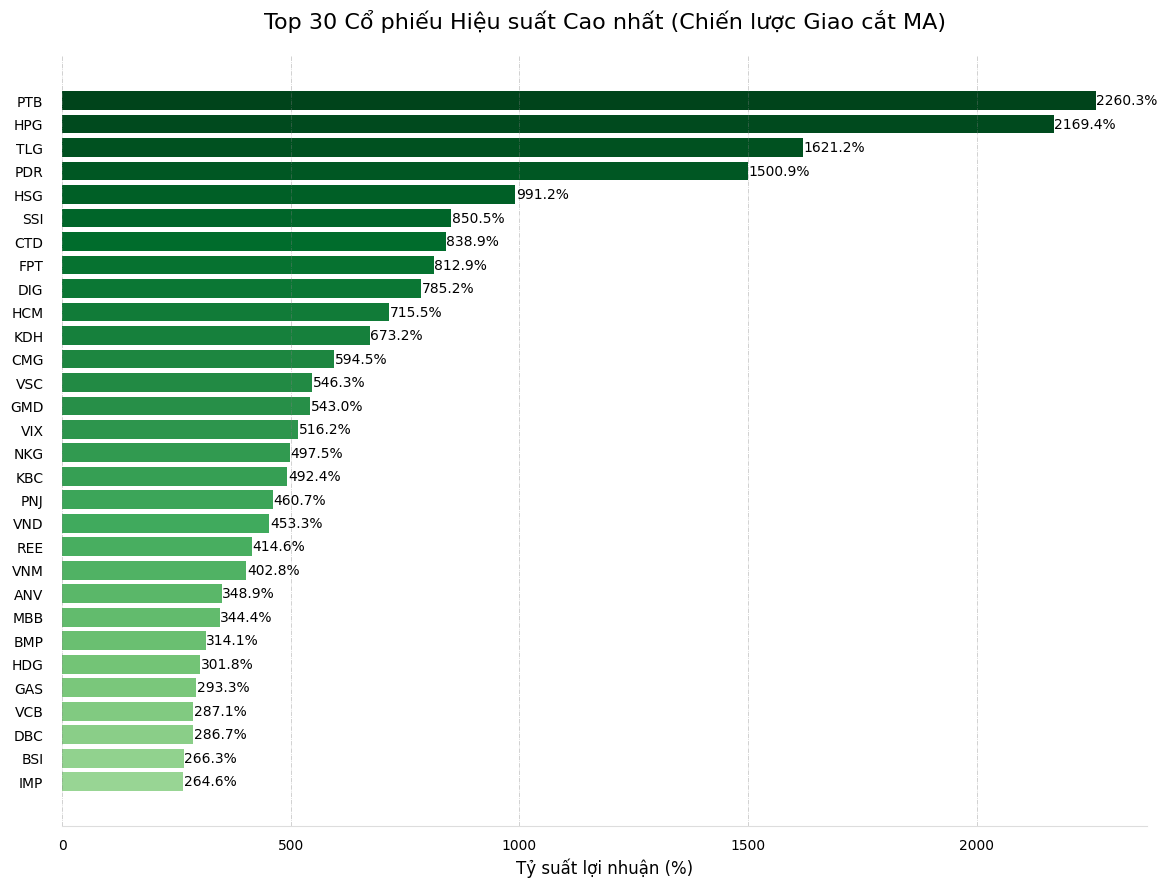

In [ ]:
# Bước 1: Khai báo các thư viện cần thiết
import pandas as pd
import backtrader as bt
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Bước 2: Định nghĩa chiến lược giao dịch (Không thay đổi)
class MAcrossStrategy(bt.Strategy):
    params = dict(ma_short_period=20, ma_long_period=50)

    def __init__(self):
        self.ma_short = bt.indicators.MovingAverageSimple(self.data.close, period=self.p.ma_short_period, plotname='MA 20')
        self.ma_long = bt.indicators.MovingAverageSimple(self.data.close, period=self.p.ma_long_period, plotname='MA 50')
        self.crossover = bt.indicators.CrossOver(self.ma_short, self.ma_long)
        self.last_order = None
        self.buy_price = None
        self.trade_profits_pct = []
        self.sell_dates = []

    def next(self):
        if self.crossover > 0 and not self.position:  # MA ngắn cắt lên MA dài, không có vị thế
            self.last_order = 'buy'
            self.buy_price = self.data.close[0]
            self.buy(size=None)
            print(f'BUY CREATE, {self.data.datetime.date(0)}, Price: {self.data.close[0]:.2f}')
        elif self.crossover < 0 and self.position:  # MA ngắn cắt xuống MA dài, đang có vị thế
            self.last_order = 'sell'
            sell_price = self.data.close[0]
            self.sell(size=self.position.size)  # Bán toàn bộ vị thế
            profit_pct = (sell_price - self.buy_price) / self.buy_price
            self.trade_profits_pct.append(profit_pct)
            self.sell_dates.append(self.data.datetime.date(0))
            print(f'SELL CREATE, {self.data.datetime.date(0)}, Price: {self.data.close[0]:.2f}')

    def stop(self):
        if self.last_order == 'buy' and self.position:  # Đóng vị thế mua nếu còn mở
            sell_price = self.data.close[0]
            self.sell(size=self.position.size)
            profit_pct = (sell_price - self.buy_price) / self.buy_price
            self.trade_profits_pct.append(profit_pct)
            self.sell_dates.append(self.data.datetime.date(0))
            print(f'SELL all at the end, {self.data.datetime.date(0)}, Price: {self.data.close[0]:.2f}')


# Bước 3: Tải dữ liệu và thực thi backtest (Không thay đổi)
# Load the Excel file
file_path = "du_lieu_tcbs_vn.xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

# Get unique stock symbols
symbols = df['symbol'].unique()

# Initialize lists to store results
R_ma_check = []
ticker_ma_check = []

# Execute the strategy for each symbol
for i in symbols:
    try:
        # Filter data for the current symbol
        DT = df[df['symbol'] == i][['time', 'open', 'high', 'low', 'close', 'volume']].copy()
        DT = DT.set_index('time')

        # Filter data for the study period (2012-01-01 to 2024-12-30)
        DT_study_period = DT[(DT.index >= '2012-01-01') & (DT.index <= '2024-12-30')]
        if DT_study_period.empty:
            print(f"{i}: No data available in the study period (2012-01-01 to 2024-12-30)")
            continue
        if len(DT_study_period) < 1250:
            print(f"{i}: Insufficient data in the study period ({len(DT_study_period)} days, minimum required 1250 days)")
            continue

        # Prepare data for backtrader
        data = bt.feeds.PandasData(dataname=DT_study_period)

        # Execute the strategy
        cerebro = bt.Cerebro()
        cerebro.addstrategy(MAcrossStrategy)
        cerebro.adddata(data)
        cerebro.broker.setcash(100000000)  # 100 million VND
        cerebro.broker.setcommission(commission=0.0015)  # 0.15% commission
        cerebro.addsizer(bt.sizers.AllInSizerInt, percents=95)

        print(f"\nProcessing {i}:")
        before = cerebro.broker.getvalue()
        result = cerebro.run()
        after = cerebro.broker.getvalue()
        r = (after - before) / before

        ticker_ma_check.append(i)
        R_ma_check.append(r)

    except Exception as e:
        print(f"Error processing {i}: {str(e)}")
        continue

# Bước 4: Xử lý, thống kê và lưu kết quả (Không thay đổi)
# Create DataFrame with results
return_ma_check = pd.DataFrame({'Ticker': ticker_ma_check, 'Return': R_ma_check})
return_ma_check = return_ma_check.sort_values('Return', ascending=False).head(30)

print(f"\n=== TOP 30 STOCKS BY RETURN ===")
print(return_ma_check)

# Filter original data for top 30 stocks and save
top_30_symbols = return_ma_check['Ticker'].tolist()
filtered_df = df[df['symbol'].isin(top_30_symbols)]
filtered_df = filtered_df.sort_values(by=['symbol', 'time'])
filtered_df.to_excel('top_30_stocks_data.xlsx', index=False)
print(f"Filtered data for top 30 stocks saved to 'top_30_stocks_data.xlsx'")

# Create and save asset allocation list
data_selected = return_ma_check['Ticker'].tolist()
list_allo = pd.DataFrame({'Asset': data_selected})
list_allo['Allo_1'] = 1 / len(data_selected) # Equal allocation
top_20_percent = int(0.2 * len(data_selected))
bottom_80_percent = len(data_selected) - top_20_percent
if top_20_percent > 0 and bottom_80_percent > 0:
    list_allo['Allo_2'] = [0.8 / top_20_percent] * top_20_percent + [0.2 / bottom_80_percent] * bottom_80_percent
else:
    list_allo['Allo_2'] = list_allo['Allo_1']
print(f"\n=== ASSET ALLOCATION ===")
print(list_allo)

# Summary statistics
if len(return_ma_check) > 0:
    print(f"\n=== SUMMARY STATISTICS ===")
    print(f"Number of successfully processed stocks: {len(return_ma_check)}")
    print(f"Average return: {return_ma_check['Return'].mean():.2%}")
    print(f"Highest return: {return_ma_check['Return'].max():.2%} ({return_ma_check.iloc[0]['Ticker']})")
    print(f"Lowest return: {return_ma_check['Return'].min():.2%}")
else:
    print("No stocks were successfully processed!")

# Save results to Excel
return_ma_check.to_excel('backtest_results.xlsx', index=False)
list_allo.to_excel('asset_allocation.xlsx', index=False)


# --- BƯỚC 5: PHẦN VẼ BIỂU ĐỒ SÁNG TẠO ---
# Chuẩn bị dữ liệu (sắp xếp lại để vẽ biểu đồ ngang cho đẹp)
df_plot = return_ma_check.sort_values('Return', ascending=True)

# Tạo dải màu chuyển tiếp từ xanh nhạt sang xanh đậm
colors = cm.Greens(np.linspace(0.4, 1, len(df_plot['Return'])))

# Bắt đầu vẽ
fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(df_plot['Ticker'], df_plot['Return'] * 100, color=colors)

# Xóa các đường viền không cần thiết để biểu đồ trông thoáng hơn
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#DDDDDD')

# Tùy chỉnh các đường kẻ và nhãn
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
ax.xaxis.set_tick_params(pad=5)
ax.yaxis.set_tick_params(pad=10)
ax.grid(color='grey', linestyle='-.', linewidth=0.5, alpha=0.5, axis='x')

# Thêm nhãn dữ liệu vào cuối mỗi thanh để hiển thị con số chính xác
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + 1  # Đặt nhãn cách thanh một chút để không bị dính
    ax.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
            va='center', ha='left', fontsize=10)

# Đặt tiêu đề và nhãn trục
ax.set_xlabel('Tỷ suất lợi nhuận (%)', fontsize=12)
ax.set_title('Top 30 Cổ phiếu Hiệu suất Cao nhất (Chiến lược Giao cắt MA)', fontsize=16, pad=20)

# Lưu và hiển thị biểu đồ
plt.savefig('top_30_returns_horizontal_gradient.png', dpi=300, bbox_inches='tight')
print("\nBiểu đồ đã được lưu vào file 'top_30_returns_horizontal_gradient.png'")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# ============== Helper: date format "M/D/YYYY" (không số 0 đứng đầu) ==============
def format_mdy_no_leading_zero(dt: pd.Timestamp) -> str:
    if pd.isna(dt):
        return ""
    return f"{dt.month}/{dt.day}/{dt.year}"

# ============== Technical Indicators ==============
def ema(series, span):
    return series.ewm(span=span, adjust=False, min_periods=span).mean()

def rsi(series, window=30):
    delta = series.diff()
    up = np.where(delta > 0, delta, 0.0)
    down = np.where(delta < 0, -delta, 0.0)
    roll_up = pd.Series(up, index=series.index).rolling(window, min_periods=window).mean()
    roll_down = pd.Series(down, index=series.index).rolling(window, min_periods=window).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

def macd_line(series, fast=12, slow=26):
    ema_fast = ema(series, fast)
    ema_slow = ema(series, slow)
    return ema_fast - ema_slow

def bollinger(series, window=20, num_std=2.0):
    ma = series.rolling(window, min_periods=window).mean()
    sd = series.rolling(window, min_periods=window).std(ddof=0)
    ub = ma + num_std * sd
    lb = ma - num_std * sd
    return ub, lb

def cci(high, low, close, window=30):
    tp = (high + low + close) / 3.0
    sma_tp = tp.rolling(window, min_periods=window).mean()
    mad = (tp - sma_tp).abs().rolling(window, min_periods=window).mean()
    return (tp - sma_tp) / (0.015 * (mad + 1e-12))

def adx(high, low, close, window=30):
    high_shift = high.shift(1)
    low_shift = low.shift(1)
    close_shift = close.shift(1)

    tr = pd.concat([
        (high - low),
        (high - close_shift).abs(),
        (low - close_shift).abs()
    ], axis=1).max(axis=1)

    plus_dm = (high - high_shift)
    minus_dm = (low_shift - low)
    plus_dm = np.where((plus_dm > minus_dm) & (plus_dm > 0), plus_dm, 0.0)
    minus_dm = np.where((minus_dm > plus_dm) & (minus_dm > 0), minus_dm, 0.0)
    plus_dm = pd.Series(plus_dm, index=high.index)
    minus_dm = pd.Series(minus_dm, index=high.index)

    atr = tr.rolling(window, min_periods=window).mean()
    plus_di = 100 * (plus_dm.rolling(window, min_periods=window).mean() / (atr + 1e-12))
    minus_di = 100 * (minus_dm.rolling(window, min_periods=window).mean() / (atr + 1e-12))

    dx = 100 * ( (plus_di - minus_di).abs() / ((plus_di + minus_di) + 1e-12) )
    adx_val = dx.rolling(window, min_periods=window).mean()
    return adx_val

# ============== Pipeline chính ==============
# Đường dẫn input (đổi theo file của bạn)
INPUT_XLSX = "top_30_stocks_data.xlsx"

# Đường dẫn output
OUT_TRAIN = "trainvn_risk.xlsx"
OUT_TEST  = "testvn_risk.xlsx"

# Đọc dữ liệu gốc
raw = pd.read_excel(INPUT_XLSX)

# NEW: Tự động đổi tên cột 'ticker' hoặc 'tic' thành 'symbol' để thống nhất
if 'ticker' in raw.columns:
    raw.rename(columns={'ticker': 'symbol'}, inplace=True)
elif 'tic' in raw.columns:
    raw.rename(columns={'tic': 'symbol'}, inplace=True)

# Chuẩn kiểu ngày
raw['date'] = pd.to_datetime(raw['date'])

# Bảo đảm sắp xếp ngày trước, rồi mã
raw = raw.sort_values(['date', 'symbol']).reset_index(drop=True)

# FIX: Loại bỏ các dòng có (date, symbol) trùng lặp, chỉ giữ lại dòng đầu tiên.
raw = raw.drop_duplicates(subset=['date', 'symbol'], keep='first')

# Tính indicators theo từng mã
def calc_indicators_group(g):
    g = g.sort_values('date').copy()
    g['log-return'] = np.log(g['close'] / g['close'].shift(1))
    g['rsi_30'] = rsi(g['close'], window=30)
    g['macd'] = macd_line(g['close'], fast=12, slow=26)
    ub, lb = bollinger(g['close'], window=20, num_std=2.0)
    g['boll_ub'] = ub
    g['boll_lb'] = lb
    g['cci_30'] = cci(g['high'], g['low'], g['close'], window=30)
    g['dx_30'] = adx(g['high'], g['low'], g['close'], window=30)
    g['close_30_sma'] = g['close'].rolling(30, min_periods=30).mean()
    g['close_60_sma'] = g['close'].rolling(60, min_periods=60).mean()
    return g

feat = raw.groupby('symbol', group_keys=False).apply(calc_indicators_group)

# Sắp xếp đúng yêu cầu
feat = feat.sort_values(['date', 'symbol']).reset_index(drop=True)

# Chuyển date về chuỗi "M/D/YYYY"
feat['date'] = feat['date'].apply(format_mdy_no_leading_zero)

# Chia train/test theo ngày
to_ts = pd.to_datetime(feat['date'], format='%m/%d/%Y')
train_mask = (to_ts >= pd.Timestamp(2013,12,31)) & (to_ts <= pd.Timestamp(2022,1,1))
test_mask  = (to_ts >= pd.Timestamp(2021,12,31)) & (to_ts <= pd.Timestamp(2025,12,31))

# Cập nhật thứ tự cột với 'symbol'
cols_order = ['date','symbol','open','high','low','close','volume',
              'log-return','rsi_30','macd','boll_ub','boll_lb',
              'cci_30','dx_30','close_30_sma','close_60_sma']

train_df = feat.loc[train_mask, cols_order].sort_values(['date','symbol'])
test_df  = feat.loc[test_mask,  cols_order].sort_values(['date','symbol'])

# Ghi ra Excel (mỗi file 1 sheet duy nhất)
train_df.to_excel(OUT_TRAIN, index=False)
test_df.to_excel(OUT_TEST, index=False)

print("Done:",
      f"\n  Train rows: {len(train_df)} -> {OUT_TRAIN}",
      f"\n  Test  rows: {len(test_df)} -> {OUT_TEST}")

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
/tmp/ipython-input-2264568587.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2 = float(X.T @ inv @ X)
/tmp/ipython-input-2264568587.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2 = float(X.T @ inv @ X)
/tmp/ipython-input-2264568587.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  d2 = float(X.T @ inv @ X)
/tmp/ipython-input-2264568587.py:106: DeprecationWarning: Conversion of an array w

Done: 
  Train rows: 59853 -> trainvn_risk.xlsx 
  Test  rows: 25830 -> testvn_risk.xlsx
